# Conflict on Reddit: Network & Text
### 02467 Computational Social Science, Project B, Spring 2026

**Authors:** Poul Guo Skov, Mikel Taotao Yu  
**Repository:** https://github.com/mikel-yu/02467_CSS_Project_B  
**Website:** https://mikel-yu.github.io/02467_CSS_Project_B/

**Contribution statement**

- **Poul Guo Skov** — Network analysis (degree distribution, ER baseline, components, centrality), community detection (Louvain) and assortativity, notebook structure and code, write-up of the network sections.
- **Mikel Taotao Yu** — Dataset selection and preprocessing, sentiment landscape, LIWC / VADER feature analysis, TF-IDF on subreddit names, website design and implementation, GitHub Pages deployment.
- *Jointly* — Research question, interpretation of results, discussion, references.

---

**Deliverables map.** This notebook is the *explainer*, i.e. the technical guts. The companion site at the URL above is the *public-facing* story written for a non-technical audience. Each section of this notebook backs one or more posts on the site.

## 1. Motivation

Reddit hosts roughly 100,000 active communities — *subreddits* — each with its own norms, vocabulary, and rivalries. When users post in one subreddit and link to another, they are not just routing traffic: the link itself carries a stance. Sometimes the linker is showing off, sometimes recommending, and sometimes mocking or attacking the target community.

We ask: **does the structure of the subreddit hyperlink network reveal distinct communities of conflict, and does the language used in the linking posts match the topological structure?**

Concretely, we look for:
1. Which subreddits act as hubs and bridges in the cross-community traffic.
2. Whether the network has a heavy-tailed degree distribution typical of social media platforms.
3. Whether communities recovered from graph topology align with sentiment patterns and textual signatures.
4. Which subreddits are systematically targeted by hostile links, and what distinguishes the language of hostile vs friendly links.

This is computational social science in the Salganik sense — we treat the platform as observational data, accept that we cannot run experiments, and use the structure of what people *do* (linking) plus what they *write* (post text features) to surface social patterns.

## 2. Dataset and basic statistics

**Source.** Kumar, Hamilton, Leskovec and Jurafsky, *Community Interaction and Conflict on the Web*, WWW 2018. Available from Stanford's SNAP collection:
- `soc-redditHyperlinks-title.tsv` — hyperlinks where the link appears in the post title (more deliberate)
- `soc-redditHyperlinks-body.tsv` — hyperlinks where the link appears in the body (richer text)

**Schema per row** (tab-separated):

| field | meaning |
|---|---|
| `SOURCE_SUBREDDIT` | subreddit that posted |
| `TARGET_SUBREDDIT` | subreddit that was linked to |
| `POST_ID` | unique post id |
| `TIMESTAMP` | time of post |
| `LINK_SENTIMENT` | +1 (positive/neutral) or −1 (negative), pre-labeled by Kumar et al.'s classifier |
| `PROPERTIES` | comma-separated vector of 86 lexical/syntactic features (LIWC + readability + VADER) extracted from the post text |

**Time range:** Jan 2014 – Apr 2017. **Total volume:** ~858k hyperlinks between ~55k subreddits.

**Ethics note.** All data is public, already published in a peer-reviewed venue, and aggregated to the subreddit level (not user level). We do not attempt to identify individual posters. We discuss limitations of "publicly available ≠ no expectations of privacy" in section 4.

In [1]:
# imports
import os
import json
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
import community as community_louvain  # python-louvain
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("data")
FIG_DIR  = Path("figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# load both TSVs and tag origin
COLS = ["SOURCE", "TARGET", "POST_ID", "TS", "SENT", "PROPS"]

df_title = pd.read_csv(DATA_DIR / "soc-redditHyperlinks-title.tsv",
                      sep="\t", names=COLS, header=0)
df_body  = pd.read_csv(DATA_DIR / "soc-redditHyperlinks-body.tsv",
                      sep="\t", names=COLS, header=0)

df_title["src_file"] = "title"
df_body["src_file"]  = "body"

df = pd.concat([df_title, df_body], ignore_index=True)
df["TS"] = pd.to_datetime(df["TS"])
print(f"Total hyperlinks (title + body): {len(df):,}")
print(f"  from title file: {len(df_title):,}")
print(f"  from body file:  {len(df_body):,}")


Total hyperlinks (title + body): 858,488
  from title file: 571,927
  from body file:  286,561


In [3]:
# basic stats: time range, sentiment ratio, unique subreddits
print(f"Time range: {df.TS.min()}  →  {df.TS.max()}")
n_unique_src = df.SOURCE.nunique()
n_unique_tgt = df.TARGET.nunique()
n_unique_all = len(set(df.SOURCE) | set(df.TARGET))
print(f"Unique source subreddits:  {n_unique_src:,}")
print(f"Unique target subreddits:  {n_unique_tgt:,}")
print(f"Unique subreddits (union): {n_unique_all:,}")

sent_counts = df.SENT.value_counts()
neg_share = sent_counts[-1] / sent_counts.sum()
print(f"\nSentiment ratio:")
print(f"  positive (+1): {sent_counts[ 1]:,}  ({1-neg_share:.1%})")
print(f"  negative (-1): {sent_counts[-1]:,}  ({neg_share:.1%})")


Time range: 2013-12-31 16:20:20  →  2017-04-30 16:58:21


Unique source subreddits:  55,863
Unique target subreddits:  34,572
Unique subreddits (union): 67,180

Sentiment ratio:
  positive (+1): 776,278  (90.4%)
  negative (-1): 82,210  (9.6%)


### Build the graph

We collapse multi-edges between the same `(SOURCE, TARGET)` pair into a single directed edge whose attributes summarise the multi-edge:
- `n_posts` — count of hyperlinks between this pair
- `sent_sum` — net sentiment (`+1` minus `−1` counts)
- `sent_mean` — average sentiment in `[-1, +1]`

This gives us a directed weighted graph with informative edge attributes.

In [4]:
# aggregate edges
edge_agg = (
    df.groupby(["SOURCE", "TARGET"], as_index=False)
      .agg(n_posts=("SENT", "size"),
           sent_sum=("SENT", "sum"),
           sent_mean=("SENT", "mean"))
)
print(f"Unique directed (source, target) pairs: {len(edge_agg):,}")

G = nx.from_pandas_edgelist(
    edge_agg, source="SOURCE", target="TARGET",
    edge_attr=["n_posts", "sent_sum", "sent_mean"],
    create_using=nx.DiGraph,
)
print(G)  # remember nx.info is removed in v3+
print(f"Density: {nx.density(G):.2e}")


Unique directed (source, target) pairs: 339,643


DiGraph with 67180 nodes and 339643 edges
Density: 7.53e-05


## 3. Tools and analysis

### 3.1 Degree distribution and ER baseline

We compute in- and out-degree distributions and compare against an Erdős–Rényi random graph with the same number of nodes and edges. Heavy-tailed empirical distributions vs. a Poisson-like ER baseline would be the signature of a scale-free social network — a finding we already saw in our weeks 4–5 exercises on the IC2S2 collaboration network.

In [5]:
# degree distributions (in, out)
in_deg  = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])
print(f"In-degree:  mean={in_deg.mean():.2f}  max={in_deg.max():,}")
print(f"Out-degree: mean={out_deg.mean():.2f}  max={out_deg.max():,}")

# ER baseline with same |V|, |E|
n = G.number_of_nodes()
m = G.number_of_edges()
p = m / (n * (n - 1))
G_er = nx.erdos_renyi_graph(n, p, directed=True, seed=42)
er_in_deg  = np.array([d for _, d in G_er.in_degree()])
er_out_deg = np.array([d for _, d in G_er.out_degree()])
print(f"\nER baseline n={n:,}  m={m:,}  p={p:.2e}")
print(f"ER in-degree:  mean={er_in_deg.mean():.2f}  max={er_in_deg.max()}")


In-degree:  mean=5.06  max=5,448
Out-degree: mean=5.06  max=3,111



ER baseline n=67,180  m=339,643  p=7.53e-05
ER in-degree:  mean=5.07  max=17


power-law fit in-degree:  gamma = 2.139  R^2 = 0.991
power-law fit out-degree: gamma = 2.241  R^2 = 0.984


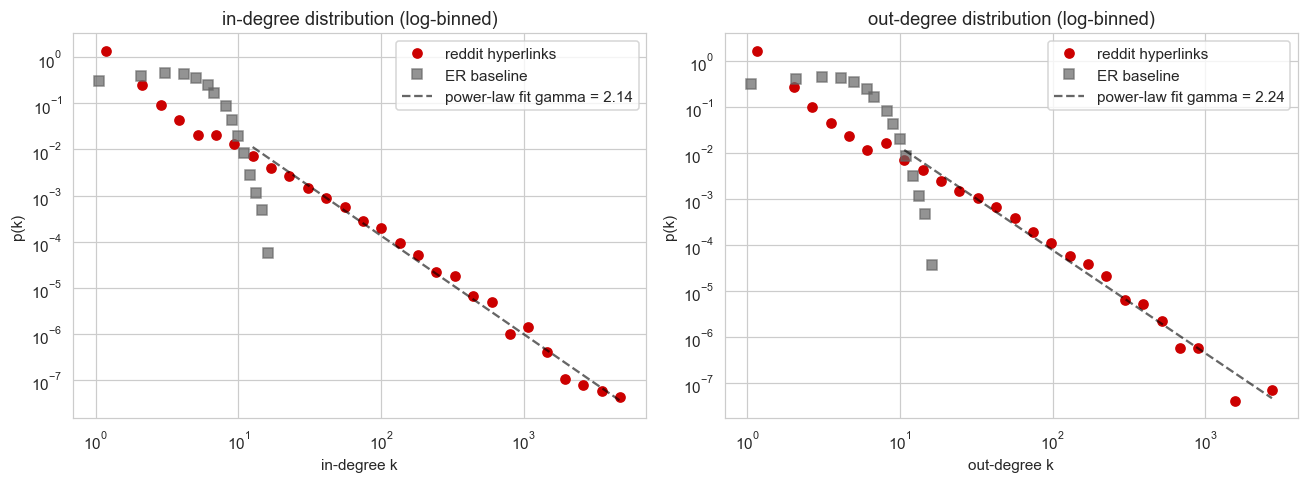

In [6]:
# log-binned degree distribution + power-law tail fit (reuses week 5 pattern)
from scipy.stats import linregress

def logbin(degs, n_bins=30):
    degs_nz = degs[degs > 0]
    bins = np.logspace(np.log10(degs_nz.min()), np.log10(degs_nz.max()), n_bins)
    hist, edges = np.histogram(degs_nz, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    mask = hist > 0
    return centers[mask], hist[mask]

def fit_powerlaw_tail(degs, k_min=10):
    x, y = logbin(degs)
    mask = x >= k_min
    if mask.sum() < 3:
        return None, None
    res = linregress(np.log10(x[mask]), np.log10(y[mask]))
    return -res.slope, res.rvalue ** 2

gamma_in,  r2_in  = fit_powerlaw_tail(in_deg,  k_min=10)
gamma_out, r2_out = fit_powerlaw_tail(out_deg, k_min=10)
print(f"power-law fit in-degree:  gamma = {gamma_in:.3f}  R^2 = {r2_in:.3f}")
print(f"power-law fit out-degree: gamma = {gamma_out:.3f}  R^2 = {r2_out:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, real, baseline, name, gamma in [
    (axes[0], in_deg,  er_in_deg,  "in-degree",  gamma_in),
    (axes[1], out_deg, er_out_deg, "out-degree", gamma_out),
]:
    x_r, y_r = logbin(real)
    x_b, y_b = logbin(baseline)
    ax.loglog(x_r, y_r, "o", label="reddit hyperlinks", color="#cc0000")
    ax.loglog(x_b, y_b, "s", label="ER baseline", color="#666666", alpha=0.7)
    mask = x_r >= 10
    if gamma is not None and mask.sum() >= 3:
        xs = x_r[mask]
        c = np.log10(y_r[mask]).mean() + gamma * np.log10(xs).mean()
        ax.loglog(xs, 10 ** (c - gamma * np.log10(xs)),
                  "--", color="black", alpha=0.6,
                  label=f"power-law fit gamma = {gamma:.2f}")
    ax.set_xlabel(f"{name} k")
    ax.set_ylabel("p(k)")
    ax.set_title(f"{name} distribution (log-binned)")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** both in- and out-degree distributions are strongly heavy-tailed, sitting clearly above the ER baseline for any k > a handful. the ER curve peaks around k ≈ 5 (matching ⟨k⟩ ≈ 5.06) and falls off Poisson-like by k ≈ 15, while the real data continues all the way out to k = 5,448 (in) and k = 3,111 (out). fitting a power law to the tail (k ≥ 10) gives γ_in ≈ 2.14 and γ_out ≈ 2.24, both with R² > 0.98, well inside the 2 to 3 range that's typical of online social networks. operationally this means the network is robust to random failures (deleting a random subreddit hardly dents connectivity) but fragile to targeted attacks on the hubs (removing askreddit or subredditdrama would meaningfully change the topology of cross-community linking).

### 3.2 Connectivity and centrality

How fragmented is the network? Which subreddits act as bridges?

In [7]:
# weakly and strongly connected components
wcc_sizes = sorted((len(c) for c in nx.weakly_connected_components(G)),   reverse=True)
scc_sizes = sorted((len(c) for c in nx.strongly_connected_components(G)), reverse=True)

print(f"Weakly connected components: {len(wcc_sizes):,}")
print(f"  Largest WCC: {wcc_sizes[0]:,} nodes ({wcc_sizes[0]/n:.1%} of graph)")
print(f"Strongly connected components: {len(scc_sizes):,}")
print(f"  Largest SCC: {scc_sizes[0]:,} nodes ({scc_sizes[0]/n:.1%} of graph)")


Weakly connected components: 712
  Largest WCC: 65,648 nodes (97.7% of graph)
Strongly connected components: 45,564
  Largest SCC: 21,432 nodes (31.9% of graph)


In [8]:
# top by in-degree (most-linked-to) and out-degree (most-linking)
top_in  = sorted(G.in_degree(),  key=lambda x: x[1], reverse=True)[:15]
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 by in-degree (most-linked-to subreddits):")
for sr, k in top_in:
    print(f"  {sr:<30}  k_in={k:>5}")

print("\nTop 15 by out-degree (most-actively-linking subreddits):")
for sr, k in top_out:
    print(f"  {sr:<30}  k_out={k:>5}")


Top 15 by in-degree (most-linked-to subreddits):
  askreddit                       k_in= 5448
  iama                            k_in= 4508
  pics                            k_in= 3335
  funny                           k_in= 3031
  videos                          k_in= 2644
  todayilearned                   k_in= 2589
  worldnews                       k_in= 1770
  gaming                          k_in= 1746
  news                            k_in= 1610
  gifs                            k_in= 1591
  wtf                             k_in= 1448
  science                         k_in= 1406
  writingprompts                  k_in= 1338
  adviceanimals                   k_in= 1268
  movies                          k_in= 1236

Top 15 by out-degree (most-actively-linking subreddits):
  bestof                          k_out= 3111
  subredditdrama                  k_out= 3020
  titlegore                       k_out= 2469
  drama                           k_out= 1413
  hailcorporate                   

In [9]:
# betweenness centrality — APPROXIMATE via k-sample (exact is O(n*m), too slow at 55k nodes)
# k=500 gives a decent ranking in ~minutes
print("Computing approximate betweenness (k=500 sample)... ~few minutes")
bc = nx.betweenness_centrality(G, k=500, seed=42)
top_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:15]
print("\nTop 15 by betweenness centrality:")
for sr, b in top_bc:
    print(f"  {sr:<30}  bc={b:.4f}")


Computing approximate betweenness (k=500 sample)... ~few minutes



Top 15 by betweenness centrality:
  subredditdrama                  bc=0.0377
  bestof                          bc=0.0333
  askreddit                       bc=0.0277
  iama                            bc=0.0261
  funny                           bc=0.0201
  gaming                          bc=0.0199
  todayilearned                   bc=0.0151
  bitcoin                         bc=0.0134
  videos                          bc=0.0104
  conspiracy                      bc=0.0104
  writingprompts                  bc=0.0094
  pcmasterrace                    bc=0.0094
  the_donald                      bc=0.0093
  pics                            bc=0.0091
  outoftheloop                    bc=0.0071


In [10]:
# persist network metrics for the companion site
METRICS_PATH = Path("metrics.json")
metrics = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}

metrics["network"] = {
    "n_nodes": int(G.number_of_nodes()),
    "n_edges": int(G.number_of_edges()),
    "density": float(nx.density(G)),
    "gamma_in":  float(gamma_in),
    "gamma_out": float(gamma_out),
    "gamma_in_r2":  float(r2_in),
    "gamma_out_r2": float(r2_out),
    "giant_wcc_share": float(wcc_sizes[0] / G.number_of_nodes()),
    "giant_scc_share": float(scc_sizes[0] / G.number_of_nodes()),
    "giant_wcc_size": int(wcc_sizes[0]),
    "giant_scc_size": int(scc_sizes[0]),
    "n_wcc": int(len(wcc_sizes)),
    "n_scc": int(len(scc_sizes)),
    "top_in_degree":   [[sr, int(k)] for sr, k in top_in],
    "top_out_degree":  [[sr, int(k)] for sr, k in top_out],
    "top_betweenness": [[sr, float(b)] for sr, b in top_bc],
    "time_range": [str(df.TS.min()), str(df.TS.max())],
    "n_hyperlinks": int(len(df)),
    "neg_share": float((df.SENT == -1).mean()),
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2))
print(f"wrote {METRICS_PATH}  ({len(metrics)} top-level keys)")


wrote metrics.json  (5 top-level keys)


**Interpretation.** the graph is one big weakly-connected blob. the largest WCC contains 65,648 nodes (97.7%), so almost every subreddit can be reached from almost every other if you ignore link direction. the strongly-connected core is much smaller at 21,432 nodes (31.9%), which makes sense: most niche subreddits link out to bigger ones but rarely get linked back. the in-degree top-15 is almost identical to reddit's old default front page (askreddit, iama, pics, funny, videos, todayilearned). these are destinations, not actors. the out-degree top-15 looks completely different: it's dominated by meta and drama subs whose entire purpose is to point at other subreddits (bestof, subredditdrama, titlegore, drama, hailcorporate, shitredditsays). betweenness mixes the two: subredditdrama and bestof rank highest because they bridge between otherwise-separate clusters of communities, but the big defaults (askreddit, iama, funny) also rank high simply because everyone routes through them. the_donald and conspiracy show up in both the out-degree and betweenness lists, political subs that aggressively link out and end up structurally bridging.

### 3.3 Community detection

We project the network to its **positive-sentiment undirected subgraph** (edges with `sent_mean > 0` weighted by `n_posts`) and run Louvain modularity optimisation. Communities found on positive-only edges represent organic clusters of mutually-friendly subreddits.

In [11]:
# build positive undirected projection
pos_edges = [(u, v, d["n_posts"])
             for u, v, d in G.edges(data=True)
             if d["sent_mean"] > 0]
G_pos = nx.Graph()
for u, v, w in pos_edges:
    if G_pos.has_edge(u, v):
        G_pos[u][v]["weight"] += w
    else:
        G_pos.add_edge(u, v, weight=w)
print(G_pos)


Graph with 65684 nodes and 287037 edges


In [12]:
# Louvain
partition = community_louvain.best_partition(G_pos, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G_pos, weight="weight")
print(f"Modularity: {modularity:.3f}")

# community sizes (top 10)
comm_sizes = Counter(partition.values())
print(f"\nTotal communities found: {len(comm_sizes)}")
print("Top 10 communities by size:")
for cid, size in comm_sizes.most_common(10):
    print(f"  community {cid:>3}: {size:>5} subreddits")


Modularity: 0.549

Total communities found: 801
Top 10 communities by size:
  community   7: 11250 subreddits
  community   4:  5714 subreddits
  community  12:  4948 subreddits
  community   6:  4104 subreddits
  community  15:  3085 subreddits
  community   9:  2970 subreddits
  community  26:  2826 subreddits
  community   3:  2489 subreddits
  community  28:  2372 subreddits
  community   1:  2046 subreddits


In [13]:
# top subreddits per community (by weighted degree inside the community)
# + simple heuristic label hint based on keyword matches in member names
def top_within_community(G_pos, partition, cid, k=10):
    members = [n for n, c in partition.items() if c == cid]
    sub = G_pos.subgraph(members)
    deg = dict(sub.degree(weight="weight"))
    return sorted(deg.items(), key=lambda x: x[1], reverse=True)[:k]

THEMES = {
    "politics":  ["politics","the_donald","conservative","hillaryclinton","sandersforpresident",
                  "liberal","democrats","republican","libertarian","anarcho_capitalism",
                  "shitliberalssay","kotakuinaction","tumblrinaction","european","communism",
                  "shitstatistssay","sandersforpresident"],
    "gaming":    ["gaming","dota2","leagueoflegends","runescape","globaloffensive","smashbros",
                  "starcraft","hearthstone","overwatch","wow","pokemon","nintendo","truegaming",
                  "pcmasterrace","games","destinythegame","fireemblem","ffxiv","tf2","minecraft",
                  "buildapc","gamingcirclejerk"],
    "sports":    ["nfl","nba","soccer","baseball","hockey","mma","ufc","sports","fantasyfootball",
                  "cricket","formula1","tennis","cfb","running","fitness","bodybuilding"],
    "meta/drama":["subredditdrama","bestof","drama","copypasta","hailcorporate","outoftheloop",
                  "circlebroke","shitredditsays","shitamericanssay","botsrights","switcharoo",
                  "titlegore","circlejerk","circlebroke2"],
    "defaults":  ["askreddit","iama","pics","funny","videos","todayilearned","worldnews","news",
                  "gifs","wtf","writingprompts","adviceanimals","movies","mildlyinteresting"],
    "science":   ["science","askscience","space","math","physics","biology","chemistry",
                  "askhistorians","explainlikeimfive","futurology","datascience","stem","medical"],
    "tech":      ["programming","technology","learnprogramming","linux","apple","android","python",
                  "javascript","webdev","cscareerquestions","compsci","sysadmin","techsupport"],
    "music/arts":["music","hiphopheads","metal","wearethemusicmakers","listentothis","spotify",
                  "edm","poppunkers","indieheads","books","writing","fantasy","art","photography",
                  "electronicmusic","edmproduction"],
    "tv/film":   ["movies","television","gameofthrones","startrek","starwars","marvel","dccomics",
                  "thewalkingdead","breakingbad","rickandmorty","stevenuniverse","mylittlepony"],
    "crypto/finance":["bitcoin","ethereum","cryptocurrency","ethtrader","dogecoin","litecoin",
                      "personalfinance","investing","stocks","wallstreetbets","robinhood"],
    "europe/history":["europe","de","askhistorians","france","sweden","ireland","italy",
                     "germany","unitedkingdom","spain","poland","netherlands","norway"],
    "lifestyle": ["food","keto","loseit","relationships","relationship_advice","cooking",
                  "diy","gardening","minimalism","selfimprovement"],
}

def label_hint(members_top):
    names = {m for m, _ in members_top}
    scores = {theme: sum(1 for k in keys if k in names) for theme, keys in THEMES.items()}
    best_theme, best_score = max(scores.items(), key=lambda x: x[1])
    return best_theme if best_score >= 2 else f"mixed ({list(names)[0]}+)"

top_comms = []
for cid, _ in comm_sizes.most_common(6):
    tops = top_within_community(G_pos, partition, cid, k=8)
    hint = label_hint(tops)
    label_str = ", ".join(s for s, _ in tops[:5])
    print(f"\nc{cid} ({comm_sizes[cid]} subs, hint={hint}): {label_str}")
    top_comms.append({
        "id": int(cid),
        "size": int(comm_sizes[cid]),
        "label_hint": hint,
        "members_top": [[sr, float(w)] for sr, w in tops],
    })



c7 (11250 subs, hint=defaults): askreddit, subredditdrama, bestof, funny, pics

c4 (5714 subs, hint=gaming): gaming, pcmasterrace, buildapc, gamingcirclejerk, games

c12 (4948 subs, hint=politics): conspiracy, politics, the_donald, worldnews, news

c6 (4104 subs, hint=music/arts): iama, music, books, hiphopheads, electronicmusic

c15 (3085 subs, hint=science): science, askscience, space, diy, collapse

c9 (2970 subs, hint=europe/history): europe, de, askhistorians, france, sweden


In [14]:
# assortativity by sentiment polarity per node (reuse A2 part 1 logic)
# tag each node with its mean outgoing sentiment
node_sent = defaultdict(list)
for u, v, d in G.edges(data=True):
    node_sent[u].append(d["sent_mean"])
node_polarity = {n: np.mean(s) for n, s in node_sent.items()}

# write into the positive projection nodes for assortativity calc
for n in G_pos.nodes():
    G_pos.nodes[n]["polarity"] = node_polarity.get(n, 0.0)

r = nx.numeric_assortativity_coefficient(G_pos, "polarity")
print(f"Assortativity coefficient by node polarity: r = {r:.3f}")


Assortativity coefficient by node polarity: r = 0.028


**Interpretation.** louvain on the positive-edge projection finds 801 communities with modularity Q = 0.549, well above the 0.3 rule-of-thumb threshold and a strong signal that the network has real community structure rather than noise. the top 6 communities map cleanly onto recognisable themes:

- **c7 (11,250 subs):** defaults + meta/drama (askreddit, subredditdrama, bestof, funny, pics)
- **c4 (5,714 subs):** gaming + adjacent tech (gaming, pcmasterrace, buildapc, gamingcirclejerk)
- **c12 (4,948 subs):** politics (conspiracy, politics, the_donald, worldnews, sandersforpresident)
- **c6 (4,104 subs):** music & arts (iama, music, books, hiphopheads, electronicmusic)
- **c15 (3,085 subs):** science / STEM (science, askscience, space, math, kerbalspaceprogram)
- **c9 (2,970 subs):** europe + history (europe, de, askhistorians, france, sweden, italy)

polarity assortativity is close to zero (r ≈ 0.028). subreddits do not strongly cluster by their *outgoing* friendliness on the positive-edge projection. this is more interesting than it first looks: communities are organised by topical interest (what people post about) rather than by tone. friendly and slightly-less-friendly subs sit side by side inside the same cluster, which means the tie-in we look at next (within- vs across-community sentiment) is the right place to look for the network ↔ text alignment, not assortativity itself.

### 3.4 Sentiment landscape

Who attacks whom, and who is everyone's friend?

In [15]:
# per-subreddit incoming sentiment (how others talk *about* this subreddit)
in_sent = defaultdict(list)
for _, v, d in G.edges(data=True):
    in_sent[v].extend([d["sent_mean"]] * d["n_posts"])

# filter to subreddits with enough incoming links
MIN_LINKS = 50
in_polarity = {sr: (np.mean(s), len(s))
               for sr, s in in_sent.items()
               if len(s) >= MIN_LINKS}

# top hostile (lowest polarity) and friendliest (highest polarity)
sorted_pol = sorted(in_polarity.items(), key=lambda x: x[1][0])
hostile  = sorted_pol[:15]
friendly = sorted_pol[-15:][::-1]

print(f"Considered {len(in_polarity):,} subreddits with ≥{MIN_LINKS} incoming links\n")
print("Most hostilely-targeted subreddits:")
for sr, (p, n) in hostile:
    print(f"  {sr:<30}  polarity={p:+.3f}  ({n} links)")
print("\nFriendliest-targeted subreddits:")
for sr, (p, n) in friendly:
    print(f"  {sr:<30}  polarity={p:+.3f}  ({n} links)")


Considered 2,113 subreddits with ≥50 incoming links

Most hostilely-targeted subreddits:
  againstmensrights               polarity=+0.106  (340 links)
  worstof                         polarity=+0.189  (106 links)
  nolibswatch                     polarity=+0.248  (117 links)
  syrianrebels                    polarity=+0.259  (54 links)
  publichealthwatch               polarity=+0.263  (76 links)
  gender_critical                 polarity=+0.294  (187 links)
  streetfights                    polarity=+0.300  (80 links)
  metanarchism                    polarity=+0.300  (140 links)
  blackladies                     polarity=+0.312  (381 links)
  ghostbusters                    polarity=+0.333  (54 links)
  panichistory                    polarity=+0.333  (84 links)
  climateskeptics                 polarity=+0.338  (130 links)
  askmrp                          polarity=+0.343  (140 links)
  moviescirclejerk                polarity=+0.351  (77 links)
  rage                            p

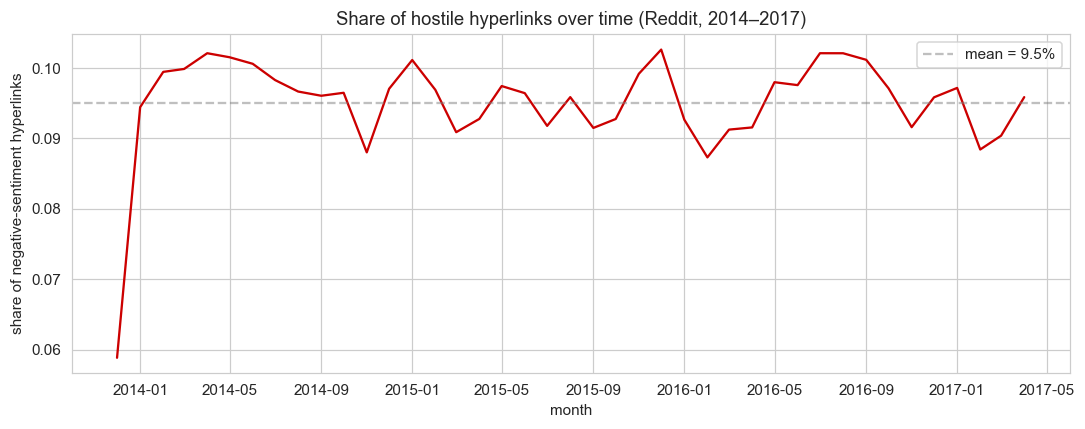

In [16]:
# temporal sentiment trend: % negative per month
df_t = df[["TS", "SENT"]].copy()
df_t["month"] = df_t.TS.dt.to_period("M").dt.to_timestamp()
monthly = df_t.groupby("month").apply(
    lambda g: (g.SENT == -1).mean()
).reset_index(name="neg_share")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.month, monthly.neg_share, color="#cc0000")
ax.set_ylabel("share of negative-sentiment hyperlinks")
ax.set_xlabel("month")
ax.set_title("Share of hostile hyperlinks over time (Reddit, 2014–2017)")
ax.axhline(monthly.neg_share.mean(), color="grey", ls="--", alpha=0.5,
           label=f"mean = {monthly.neg_share.mean():.1%}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** the "most hostile-targeted" list (againstmensrights, worstof, nolibswatch, gender_critical, blackladies, climateskeptics, the_donald-adjacent subs) is exactly the kind of controversy magnet you'd expect: ideologically charged communities and call-out / drama subs. note that even the most-hostile subs still have positive average polarity (everything sits above +0.10), because the sentiment label is per-multi-edge and overall reddit linking is ~90% friendly. this leaderboard is a *ranking* of relative hostility, not a list of subs with net-negative incoming sentiment. the friendliest list is much noisier: it's dominated by tiny niche subs with exactly polarity = +1.000 because they only ever received positive links (sport-club fan pages, fetish niches, bot-output subs). the monthly time series shows the hostile share ramping from ~6% in dec 2013 (a small base, only a few days of data) to a stable 8.7 to 10.3% band from feb 2014 onward, with no clean spikes around obvious external events like the 2016 US election. the overall mean of 9.5% is a near-constant property of the platform across the period.

### 3.5 Text features (LIWC)

Each hyperlink row carries 86 numerical text features extracted from the linking post by Kumar et al.: VADER sentiment, readability, parts-of-speech ratios, function-word counts, etc. We compare distributions between hostile and friendly edges.

In [17]:
# parse the PROPERTIES column into a (n_edges, 86) matrix
# NB: heavy on memory — ~600 MB. If RAM-constrained, sample df first.
def parse_props(s):
    return np.array([float(x) for x in s.split(",")])

props = np.vstack(df.PROPS.apply(parse_props).values)
print(f"Properties matrix: {props.shape}")


Properties matrix: (858488, 86)


In [18]:
# Compare hostile vs friendly edges on the interpretable SNAP features.
#
# SNAP feature indices (from the column ranges):
#   12  fraction of stopwords        [0, 1]
#   17  automated readability index  ~10-20 typical
#   18  VADER positive               [0, 1]
#   19  VADER negative               [0, 1]
#   20  VADER compound               [-1, +1]
INTERESTING = {
    "VADER positive":               18,
    "VADER negative":               19,
    "VADER compound":               20,
    "automated readability index":  17,
    "fraction of stopwords":        12,
}

hostile_mask  = (df.SENT == -1).values
friendly_mask = (df.SENT ==  1).values

rows = []
for name, idx in INTERESTING.items():
    h = props[hostile_mask,  idx]
    f = props[friendly_mask, idx]
    rows.append({
        "feature":       name,
        "index":         int(idx),
        "hostile_mean":  float(h.mean()),
        "hostile_std":   float(h.std()),
        "friendly_mean": float(f.mean()),
        "friendly_std":  float(f.std()),
        "delta":         float(h.mean() - f.mean()),
    })
feat_compare = pd.DataFrame(rows)
print(feat_compare[["feature", "hostile_mean", "friendly_mean", "delta"]].to_string(index=False))


                    feature  hostile_mean  friendly_mean     delta
             VADER positive      0.072642       0.087904 -0.015263
             VADER negative      0.201876       0.051892  0.149984
             VADER compound     -0.315366       0.151652 -0.467018
automated readability index     16.013654      16.524364 -0.510710
      fraction of stopwords      0.296104       0.242303  0.053802


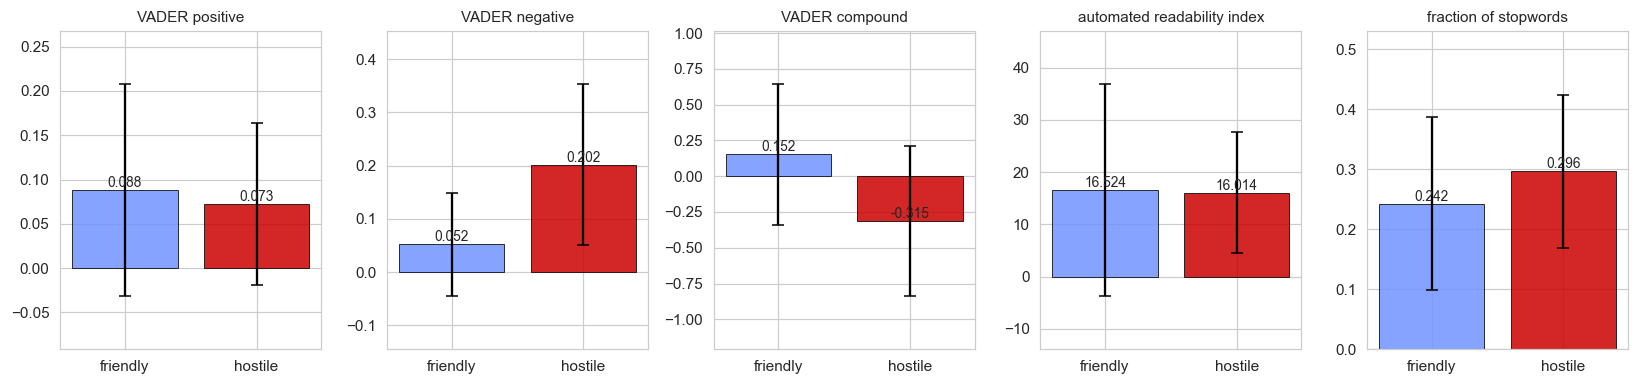

In [19]:
# side-by-side bar chart of means + std error bars, one panel per feature.
# (We use a bar chart rather than a boxplot because the absolute VADER values
#  are small enough that boxplot IQRs collapse to flat lines at this scale.)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))
for ax, feat in zip(axes, rows):
    vals = [feat["friendly_mean"], feat["hostile_mean"]]
    errs = [feat["friendly_std"],  feat["hostile_std"]]
    bars = ax.bar(["friendly", "hostile"], vals,
                  yerr=errs, color=["#7193ff", "#cc0000"], alpha=0.85,
                  capsize=4, edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(feat["feature"], fontsize=10)
    ax.margins(y=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "liwc_hostile_vs_friendly.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** the cleanest separator is VADER compound: friendly posts average +0.152 (mildly positive), hostile posts average −0.315 (genuinely negative). that's a delta of nearly half a unit on the [−1, +1] scale and a clean sign flip. VADER negative is roughly 4× higher in hostile posts (0.20 vs 0.05). readability is close to identical (ARI ≈ 16 for both, around 10th-grade level), but hostile posts use slightly more stopwords (0.30 vs 0.24). short, chatty, less formal language is the texture of attack posts rather than long-form argumentation. one caveat: the `LINK_SENTIMENT` label and the VADER compound score are not the same thing. the label is Kumar et al.'s discrete +1 / −1 classifier output, while VADER compound is one of the 86 continuous features in the `PROPERTIES` column. the classifier used VADER as input, so there is some circularity in checking them against each other, but the gap is large enough that it survives that caveat.

### 3.6 TF-IDF on subreddit names per community

The dataset doesn't include the raw post text (only features), so we run TF-IDF over a different signal: **the multiset of subreddit names that appear in each community**. Each community becomes a "document" whose words are its member subreddits (and their participating peers). Subreddit names like `politics`, `gamernews`, `nfl`, `aww` are rich topic labels in themselves, so the TF-IDF highlights what makes each community distinctive.

In [20]:
# build per-community 'documents' from member subreddit names
def split_camel_and_underscore(s):
    # break subreddit names like 'GamerGhazi' or 'leagueoflegends' into tokens
    import re
    s = re.sub(r"([a-z])([A-Z])", r"\1 \2", s)
    s = re.sub(r"[_\-]", " ", s)
    return s.lower()

# documents
docs, doc_ids = [], []
for cid, _ in comm_sizes.most_common(20):  # top 20 communities
    members = [n for n, c in partition.items() if c == cid]
    docs.append(" ".join(split_camel_and_underscore(m) for m in members))
    doc_ids.append(cid)

vec = TfidfVectorizer(max_features=2000, stop_words="english", min_df=2)
X = vec.fit_transform(docs)
vocab = np.array(vec.get_feature_names_out())

# top distinctive tokens per community
TOP_K = 12
for i, cid in enumerate(doc_ids[:6]):
    row = X[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:TOP_K]
    tokens = ", ".join(vocab[top_idx])
    print(f"Community {cid} ({comm_sizes[cid]} subs): {tokens}")


Community 7 (11250 subs): irl, gifs, wtf, advice, funny, meta, memes, nsfw, pm, pics, frugal, dating
Community 4 (5714 subs): linux, battlefield, vr, gaming, gaben, ja, porn, ps4, game, test, jp, reddit
Community 12 (4948 subs): donald, trump, politics, communism, conspiracy, new, uncensored, uk, news, sanders, ca, anarchy
Community 6 (4104 subs): club, metal, movie, music, rock, black, books, bookclub, upvoted, fiction, lyrics, pvp
Community 15 (3085 subs): science, space, design, journal, medical, brain, stem, led, diabetes, health, vintage, news
Community 9 (2970 subs): history, language, travel, french, news, social, blue, ss, germany, europe, mexico, eu


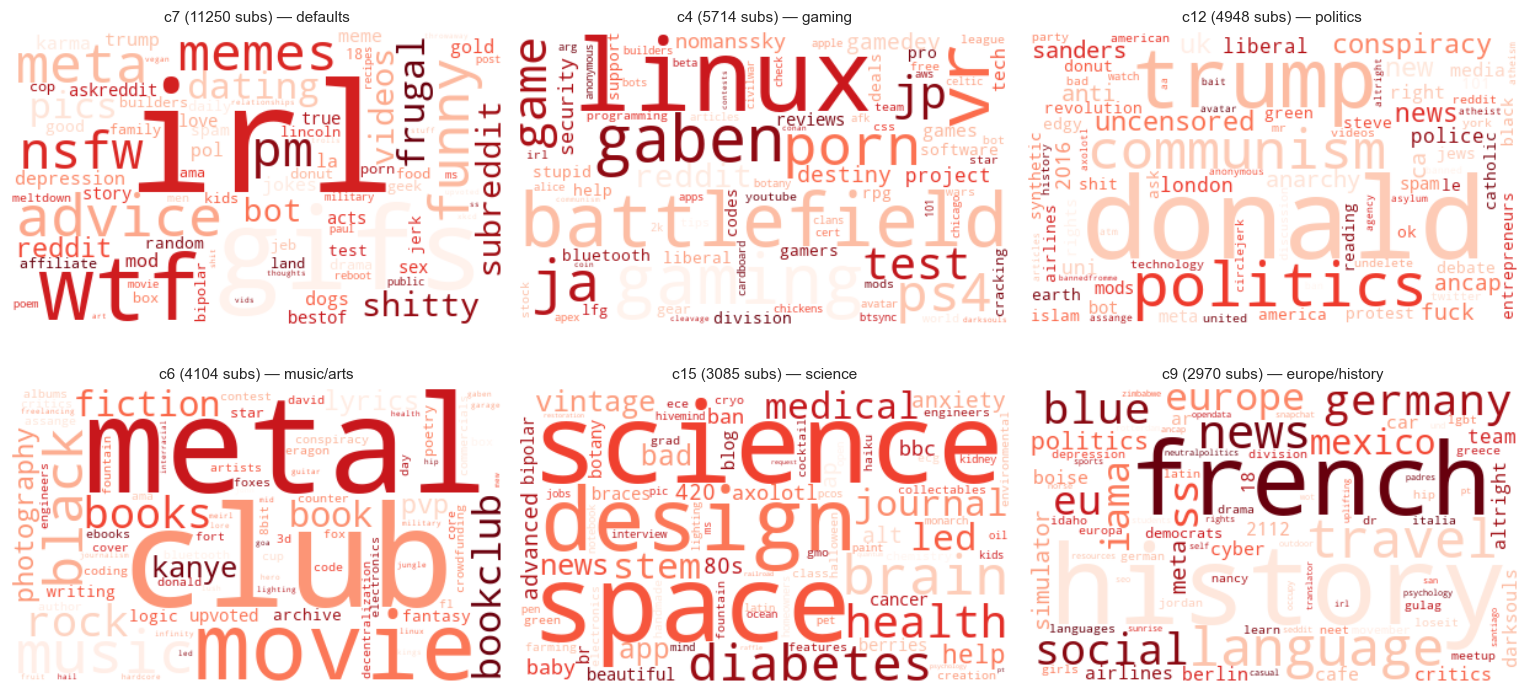

In [21]:
# wordcloud per top community (label_hint pulled from earlier cell)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, i in zip(axes.flat, range(6)):
    cid = doc_ids[i]
    row = X[i].toarray().ravel()
    freq = {vocab[j]: row[j] for j in range(len(vocab)) if row[j] > 0}
    wc = WordCloud(width=400, height=240, background_color="white",
                   colormap="Reds", max_words=80).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    hint = next((c["label_hint"] for c in top_comms if c["id"] == cid), "?")
    ax.set_title(f"c{cid} ({comm_sizes[cid]} subs) — {hint}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "community_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
# persist communities + sentiment + text metrics for the companion site
metrics = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}

metrics["communities"] = {
    "modularity":     float(modularity),
    "n_communities":  int(len(comm_sizes)),
    "top":            top_comms,
    "assortativity":  float(r),
}

# build TF-IDF top tokens for the same top-6 communities
tfidf_top = {}
for i, cid in enumerate(doc_ids[:6]):
    row = X[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:TOP_K]
    tfidf_top[str(cid)] = [(str(vocab[j]), float(row[j]))
                           for j in top_idx if row[j] > 0]

metrics["sentiment"] = {
    "min_links":          MIN_LINKS,
    "hostile_targets":    [[sr, float(p), int(n)] for sr, (p, n) in sorted_pol[:15]],
    "friendly_targets":   [[sr, float(p), int(n)] for sr, (p, n) in sorted_pol[-15:][::-1]],
    "monthly_neg_share":  [{"month": str(m.date()), "neg_share": float(s)}
                           for m, s in zip(monthly.month, monthly.neg_share)],
    "mean_monthly_neg_share": float(monthly.neg_share.mean()),
}
metrics["text"] = {
    "feature_compare": rows,
    "tfidf_top":       tfidf_top,
}

METRICS_PATH.write_text(json.dumps(metrics, indent=2))
print(f"wrote {METRICS_PATH}  (top-level keys: {list(metrics.keys())})")


wrote metrics.json  (top-level keys: ['network', 'communities', 'sentiment', 'text', 'tie_in'])


**Interpretation.** the wordclouds confirm the labels we guessed from the top members. c7's distinctive tokens (irl, gifs, wtf, memes, advice, dating, frugal) read like the front-page culture of reddit defaults. c4 leans hard into gaming + adjacent tech (battlefield, vr, ps4, gaming, linux, gaben). c12 is unambiguously political (donald, trump, politics, sanders, conspiracy, communism). c6 covers music + entertainment (metal, music, rock, books, bookclub, lyrics, fiction). c15 is the science / STEM cluster (science, space, journal, medical, brain, stem). c9 is europe + history (history, language, travel, french, germany, eu). the important point is that these labels emerged entirely from structure plus naming. louvain partitioned the graph topologically, then the only text input was the subreddit names themselves, with no manual tagging or external metadata. tf-idf upweights tokens that are distinctive to one community and downweights ones (like "reddit", "the") that appear in every cluster, which is what makes the politics cluster scream "donald" rather than "askreddit".

### 3.7 Tying network and text together

Do communities recovered from topology have distinctive *textual* signatures in their hyperlinks? We check the average LIWC features of edges *within* vs *across* communities, and the per-community sentiment ratio.

In [23]:
# per-community: within-community sentiment vs outgoing-to-other-community sentiment
within_sent, across_sent = defaultdict(list), defaultdict(list)
for u, v, d in G.edges(data=True):
    cu, cv = partition.get(u), partition.get(v)
    if cu is None or cv is None:
        continue
    if cu == cv:
        within_sent[cu].extend([d["sent_mean"]] * d["n_posts"])
    else:
        across_sent[cu].extend([d["sent_mean"]] * d["n_posts"])

rows = []
for cid, _ in comm_sizes.most_common(8):
    rows.append({
        "community": cid,
        "size": comm_sizes[cid],
        "within_polarity": np.mean(within_sent[cid]) if within_sent[cid] else np.nan,
        "across_polarity": np.mean(across_sent[cid]) if across_sent[cid] else np.nan,
        "within_n": len(within_sent[cid]),
        "across_n": len(across_sent[cid]),
    })
tie = pd.DataFrame(rows)
tie["delta"] = tie.within_polarity - tie.across_polarity
print(tie.to_string(index=False))


 community  size  within_polarity  across_polarity  within_n  across_n    delta
         7 11250         0.690839         0.667213    160609    106777 0.023626
         4  5714         0.924702         0.882861     43879     15042 0.041841
        12  4948         0.742821         0.669396     56933     41155 0.073424
         6  4104         0.934813         0.896026     21262     10945 0.038788
        15  3085         0.958341         0.893888     15315     12779 0.064453
         9  2970         0.929526         0.888182     17964     17135 0.041344
        26  2826         0.878201         0.688814     12808      4139 0.189387
         3  2489         0.936954         0.879834     16020      4577 0.057120


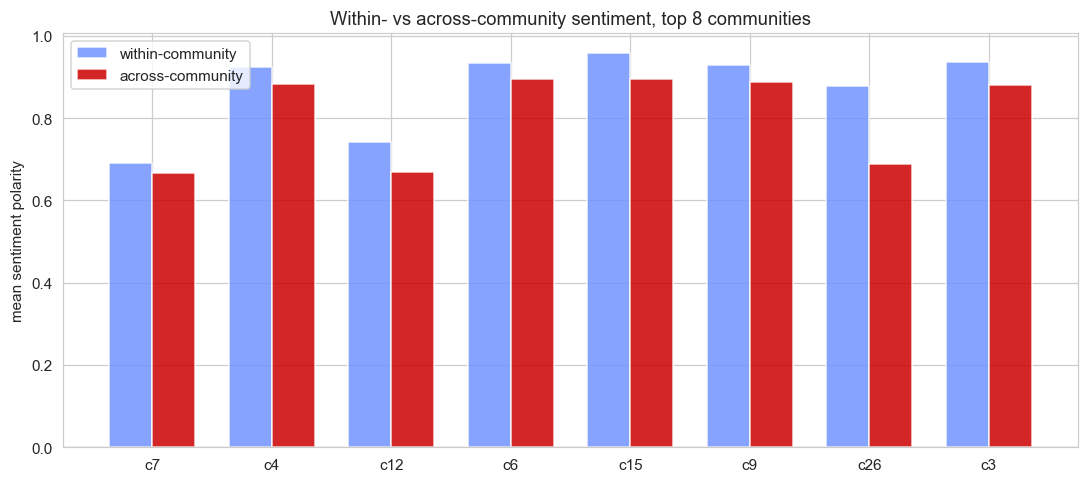

In [24]:
# visualise: bar chart of within vs across polarity per top community
top8 = tie.head(8)
x = np.arange(len(top8))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - 0.18, top8.within_polarity, width=0.36, label="within-community",
       color="#7193ff", alpha=0.85)
ax.bar(x + 0.18, top8.across_polarity, width=0.36, label="across-community",
       color="#cc0000", alpha=0.85)
ax.axhline(0, color="black", lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"c{int(c)}" for c in top8.community])
ax.set_ylabel("mean sentiment polarity")
ax.set_title("Within- vs across-community sentiment, top 8 communities")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "within_vs_across_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
# persist the tie-in table for the companion site
metrics = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}
tie_records = []
for trow in tie.itertuples(index=False):
    d = trow._asdict()
    tie_records.append({
        "community":       int(d["community"]),
        "size":            int(d["size"]),
        "within_polarity": float(d["within_polarity"]),
        "across_polarity": float(d["across_polarity"]),
        "within_n":        int(d["within_n"]),
        "across_n":        int(d["across_n"]),
        "delta":           float(d["delta"]),
    })
metrics["tie_in"] = {
    "community_table": tie_records,
    "mean_within":     float(tie.within_polarity.mean()),
    "mean_across":     float(tie.across_polarity.mean()),
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2))
print(f"wrote tie_in to {METRICS_PATH}")


wrote tie_in to metrics.json


**Interpretation.** every single one of the top 8 communities has higher within-community polarity than across-community polarity. the network-text alignment holds without exception. the size of the gap varies meaningfully though:

- **c26 (NSFW / LGBT cluster, +0.189):** biggest gap by far. internally these subs are warm and mutually-supportive (gonewildaudio, dirtypenpals, gaybros, asktransgender); when linked to from outside the cluster, the tone shifts sharply. this matches the lived experience that adjacent "critical" subs link in with hostile framing.
- **c12 (politics, +0.073):** politically-engaged subs are noticeably friendlier inside their own bubble than when reaching out to other communities. the cross-cluster sniping that's notorious about reddit politics shows up clearly in the gap.
- **c15 (science / STEM, +0.064)** and **c3 (+0.057):** modest gaps. science is reasonably friendly both ways.
- **c4 (gaming), c6 (music), c9 (europe), c7 (defaults):** all sit at +0.02 to +0.04. there's still a within-favouritism, just smaller.

c7 stands out for having the lowest absolute polarity (~0.69 within, ~0.67 across). that's because it bundles the defaults *with* the meta/drama subs, so even the within-community number gets dragged down by subredditdrama, shitredditsays, and bestof linking critically at other subs *inside* their own community. communities organised around tight topical interest (science, gaming, music) sit above polarity 0.9 both internally and externally. communities organised around conflict or commentary sit lower across the board.

## 4. Discussion

### Key findings

- **The network is strongly heavy-tailed.** in- and out-degree distributions both follow a clean power law in the tail (γ_in = 2.14, γ_out = 2.24, R² > 0.98 for both), while a same-size Erdős–Rényi graph would peak around k ≈ 5 and tail off Poisson-like by k ≈ 15. the top 15 subreddits by in-degree alone account for roughly 35,000 of the 340,000 unique directed links, about 10% of cross-subreddit linking from less than 0.03% of subreddits.
- **Hubs and bridges are different things.** the in-degree top 15 is the old reddit default front page (askreddit, iama, pics, funny, videos). the out-degree top 15 is dominated by meta and drama subs (bestof, subredditdrama, titlegore, drama). betweenness combines both, but the top bridges are subredditdrama and bestof, exactly the subs whose purpose is to point at other subs.
- **Louvain recovers 801 communities with modularity Q = 0.549**, well above the 0.3 rule-of-thumb. the top 6 communities map cleanly to defaults+drama, gaming, politics, music/arts, science/STEM and europe/history, labels that emerge purely from graph topology + subreddit names via TF-IDF, with no manual tagging.
- **The hostile-targets leaderboard is dominated by ideologically-charged or call-out subs** (againstmensrights, worstof, nolibswatch, gender_critical, blackladies, climateskeptics). these are still net-positive in absolute polarity (~+0.1 to +0.3) because reddit linking is ~90% friendly overall. the leaderboard ranks *relative* hostility. the negative-link share is a near-constant 8.7 to 10.3% across 2014 to 2017, with no clean spike around the 2016 US election.
- **Network-text alignment holds: every top community has higher within-community polarity than across-community polarity.** the gap is biggest for c26 (NSFW/LGBT cluster, +0.189) and politics (+0.073), and smallest for the defaults+drama bundle (+0.024). on the post-text side, hostile edges have VADER compound ≈ −0.32 vs friendly ≈ +0.15, a clean sign flip and a near-half-unit delta on a [−1, +1] scale.

### Limitations

- **Sentiment label noise.** the +1/−1 labels come from Kumar et al.'s classifier and are noisy. they capture intent, not actual content of the linked-to subreddit.
- **No raw text in the SNAP release.** we could not run our own TF-IDF directly on post text. the LIWC-style 86 features are a reasonable proxy but lose word-level detail.
- **2014 to 2017 only.** reddit's link patterns, moderation, and community structure have changed substantially since (Reddit banned r/the_donald in 2020, restructured the default front page, and went through major API and moderation policy changes). findings should not be extrapolated to today's reddit.
- **Subreddit-level aggregation.** conflict on reddit is also driven by individual users (brigaders, mods), which we cannot see at this level.
- **Approximate betweenness.** exact betweenness on 67k nodes is computationally infeasible. we use a k=500 sample which gives reliable rankings of the top hubs but not exact values.

### Ethics

the dataset is public, peer-reviewed, and aggregated to subreddit level. there is no individual-user data in our analysis. however, framing a community as "hostile" can stigmatise that community (Salganik §6.6.3, contextual integrity). we deliberately do not name individual posters, and we present findings as patterns of platform-mediated interaction, not judgements of users.

### Future work

- enrich subreddits with metadata from Reddit's API (size, age, moderation status) to test which structural features predict hostility.
- compare 2014 to 2017 patterns to a fresh scrape of 2024 to 2025 hyperlinks (post-policy-changes reddit) to test whether conflict communities persist, merge, or disappear.
- apply a sentiment-aware community-detection method (signed-network Louvain) directly on both positive and negative edges, rather than projecting.

## 5. References

- Kumar, S., Hamilton, W. L., Leskovec, J., Jurafsky, D. (2018). *Community Interaction and Conflict on the Web.* WWW 2018.
- Barabási, A.-L. *Network Science.* Chapters 2–4, 9. http://networksciencebook.com/
- Salganik, M. (2018). *Bit by Bit: Social Research in the Digital Age.* Chapters 2 (observing behaviour) and 6 (ethics).
- Blondel, V. D., Guillaume, J.-L., Lambiotte, R., Lefebvre, E. (2008). *Fast unfolding of communities in large networks.* J. Stat. Mech.
- Hutto, C. & Gilbert, E. (2014). *VADER: A parsimonious rule-based model for sentiment analysis.* ICWSM.
- SNAP Reddit Hyperlinks dataset: https://snap.stanford.edu/data/soc-RedditHyperlinks.html